In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.4 MB/s eta 0:01:13
   ---------------------------------------- 0.8/101.7 MB 1.6 MB/s eta 0:01:04
   ---------------------------------------- 1.0/101.7 MB 1.5 MB/s eta 0:01:08
   ---------------------------------------- 1.0/101.7 MB 1.5 MB/s eta 0:01:08
    --------------------------------------- 1.3/101.7 MB 1.2 MB/s eta 0:01:24
    --------------------------------------- 1.8/101.7 MB 1.2 MB/s eta 0:01:21
    --------------------------------------- 2.1/101.7 MB 1.3 MB/s eta 0:01:20
    --------------------------------------- 2.4/101.7 MB 1.3 MB/s eta 0:01:20
   - -------------------------------------- 2.6/101.7 MB 1.3 MB/s eta 0:01:19
   - -------------------------------------- 2.9/101.7 MB 1.3 MB/s eta 0:01:17
   - --

In [8]:
# ============================================================
# CELL 1: Import Libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42

In [11]:
# ============================================================
# CELL 2: Load Data + Basic Info
# ============================================================
df = pd.read_csv(r"C:\Users\admin\Downloads\combined cycle powerplant.csv")   # <-- update filename/path as needed

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nStatistical summary:")
display(df.describe())

Shape of dataset: (9568, 5)

First 5 rows:


,Ambient Temperature,Vacuum,Ambient Pressure,Relative Humidity,Electrical Power Output
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43



Data types:
Ambient Temperature        float64
Vacuum                     float64
Ambient Pressure           float64
Relative Humidity          float64
Electrical Power Output    float64
dtype: object

Missing values per column:
Ambient Temperature        0
Vacuum                     0
Ambient Pressure           0
Relative Humidity          0
Electrical Power Output    0
dtype: int64

Statistical summary:


,Ambient Temperature,Vacuum,Ambient Pressure,Relative Humidity,Electrical Power Output
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [12]:
# ============================================================
# CELL 3: Clean Data — Nulls + Outliers (IQR method)
# ============================================================
print("Rows before cleaning:", df.shape[0])

# --- Handle missing values ---
df = df.dropna().reset_index(drop=True)
print("Rows after dropping nulls:", df.shape[0])

# --- Outlier removal using IQR method (all numeric columns) ---
rows_before_outlier_removal = df.shape[0]

numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

df = df.reset_index(drop=True)

print("Rows before outlier removal:", rows_before_outlier_removal)
print("Rows after outlier removal:", df.shape[0])
print("Total rows removed:", rows_before_outlier_removal - df.shape[0])

Rows before cleaning: 9568
Rows after dropping nulls: 9568
Rows before outlier removal: 9568
Rows after outlier removal: 9470
Total rows removed: 98


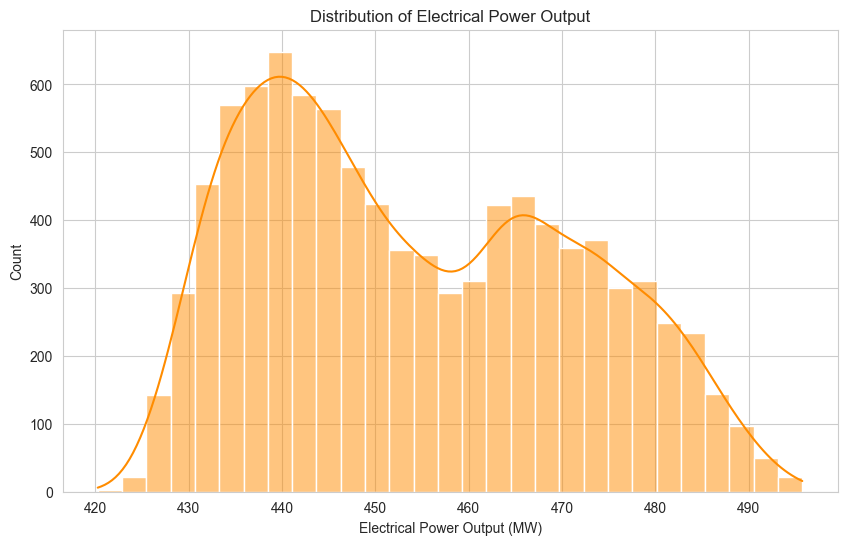

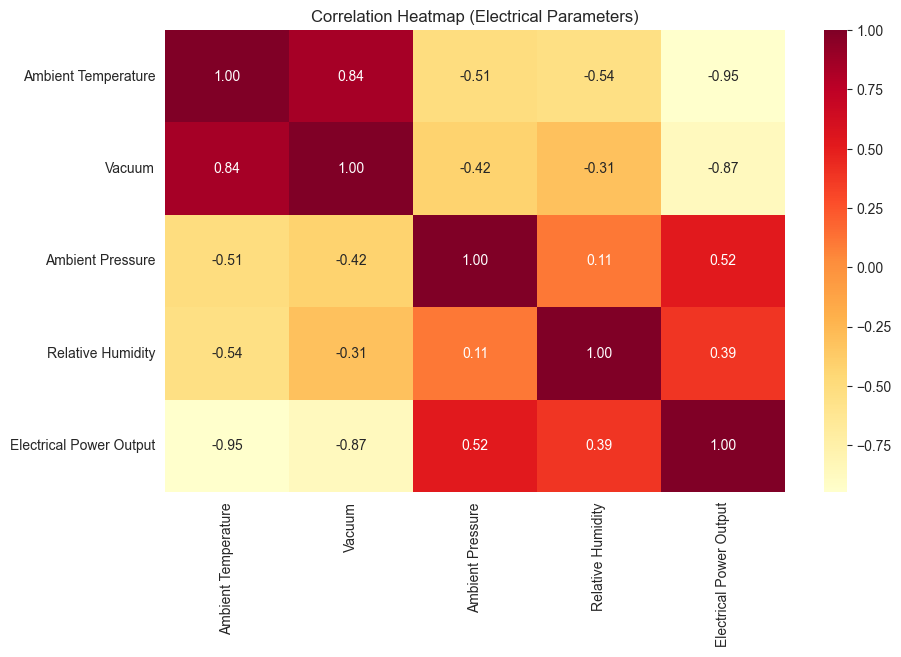

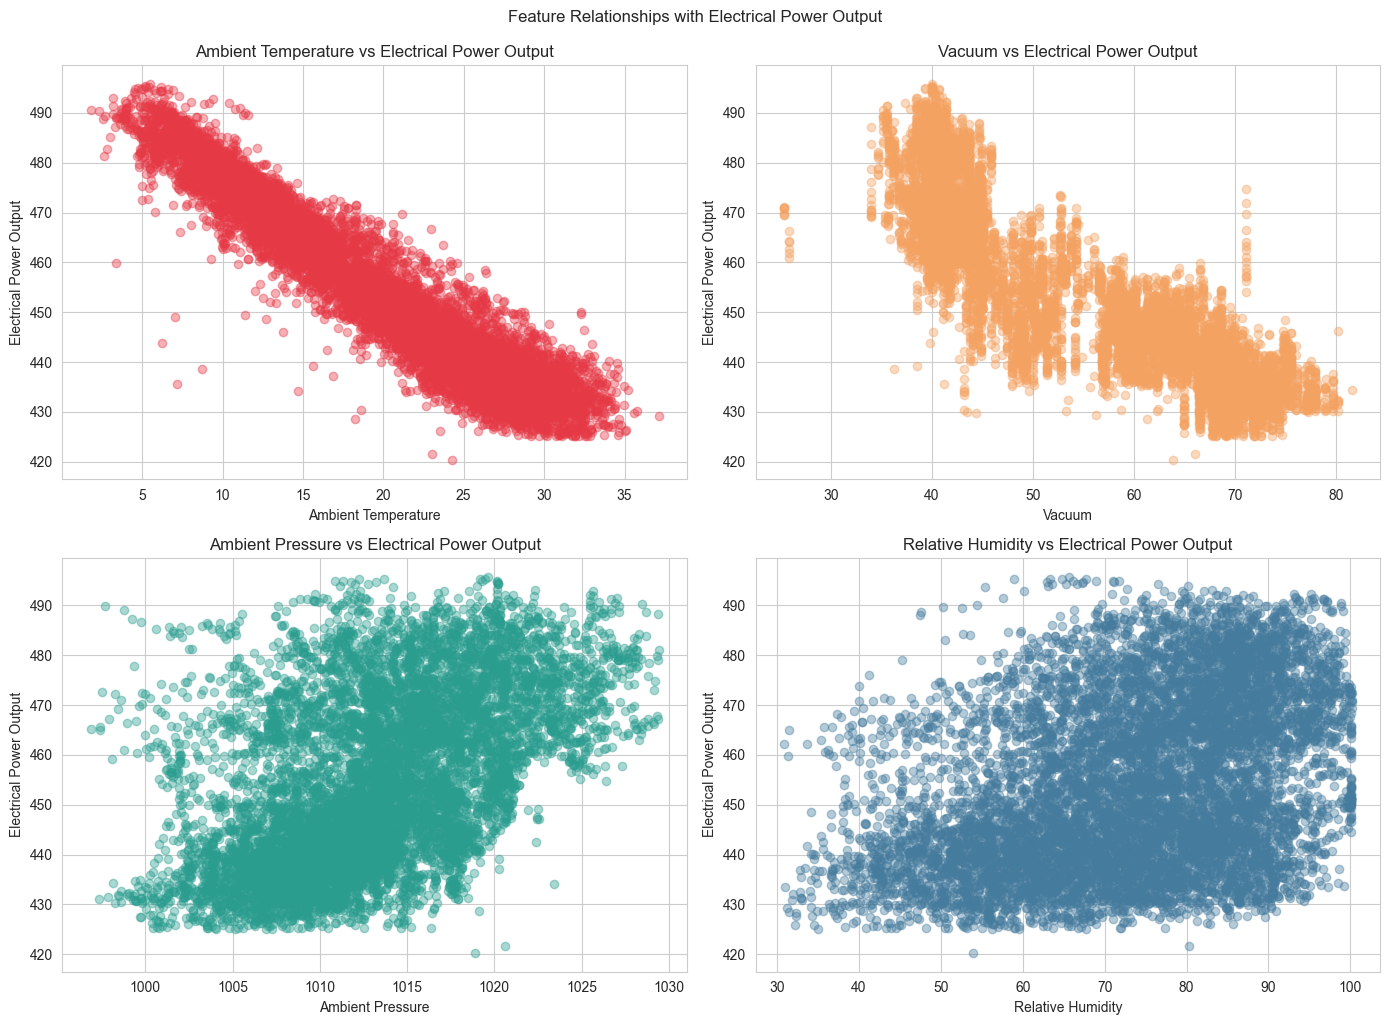

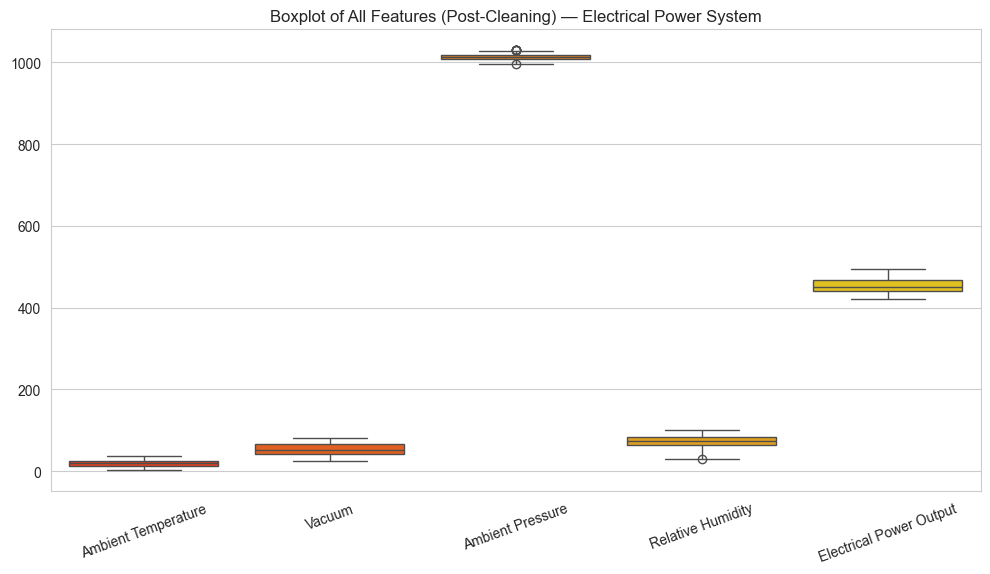

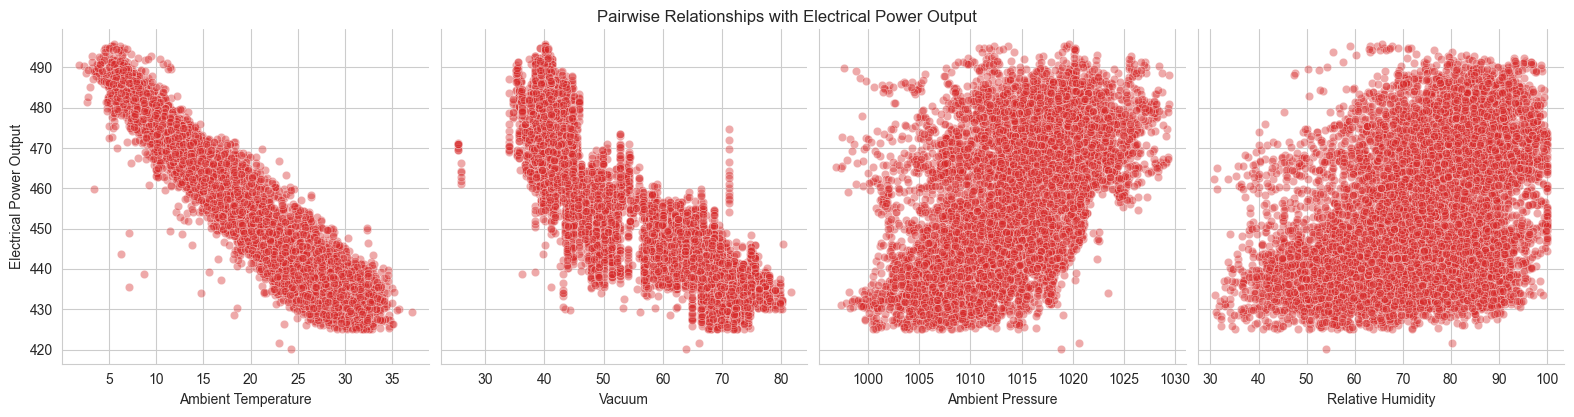

In [13]:
# ============================================================
# CELL 4: Visualization — Electrical Power Output Theme
# ============================================================
target_col = "Electrical Power Output"
feature_cols = [c for c in df.columns if c != target_col]

# --- Distribution of target ---
plt.figure()
sns.histplot(df[target_col], kde=True, color="darkorange")
plt.title("Distribution of Electrical Power Output")
plt.xlabel("Electrical Power Output (MW)")
plt.show()

# --- Correlation heatmap ---
plt.figure()
sns.heatmap(df.corr(), annot=True, cmap="YlOrRd", fmt=".2f")
plt.title("Correlation Heatmap (Electrical Parameters)")
plt.show()

# --- Scatter plots: each feature vs Electrical Power Output ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ["#e63946", "#f4a261", "#2a9d8f", "#457b9d"]

for i, col in enumerate(feature_cols):
    axes[i].scatter(df[col], df[target_col], alpha=0.4, color=colors[i % len(colors)])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Electrical Power Output")
    axes[i].set_title(f"{col} vs Electrical Power Output")

plt.tight_layout()
plt.suptitle("Feature Relationships with Electrical Power Output", y=1.02)
plt.show()

# --- Boxplots for outlier check post-cleaning ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, palette="autumn")
plt.title("Boxplot of All Features (Post-Cleaning) — Electrical Power System")
plt.xticks(rotation=20)
plt.show()

# --- Pairplot themed around Electrical Power Output ---
sns.pairplot(df, y_vars=[target_col], x_vars=feature_cols, height=4,
             plot_kws={"color": "#d62828", "alpha": 0.4})
plt.suptitle("Pairwise Relationships with Electrical Power Output", y=1.02)
plt.show()

In [14]:
# ============================================================
# CELL 5: Train-Test Split + Feature Scaling
# ============================================================
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (7576, 4)
X_test shape: (1894, 4)


In [15]:
# ============================================================
# CELL 6: Train & Compare Models
# ============================================================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(random_state=RANDOM_STATE, verbosity=0)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Train R2": train_r2, "Test R2": test_r2,
        "Train RMSE": train_rmse, "Test RMSE": test_rmse,
        "Train MAE": train_mae, "Test MAE": test_mae
    })

results_df = pd.DataFrame(results).sort_values(by="Test R2", ascending=False).reset_index(drop=True)
print("Model Comparison Table:")
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"\nBest Model: {best_model_name}")

Model Comparison Table:


,Model,Train R2,Test R2,Train RMSE,Test RMSE,Train MAE,Test MAE
0,XGBoost,0.988611,0.964132,1.814135,3.246493,1.330796,2.252371
1,Random Forest,0.994699,0.962599,1.237653,3.315165,0.877509,2.344984
2,Gradient Boosting,0.952109,0.948207,3.720123,3.901227,2.836519,2.980918
3,Linear Regression,0.927543,0.930224,4.575850,4.528095,3.637742,3.610207
4,Ridge,0.927543,0.930222,4.575852,4.528186,3.637885,3.610424
5,Lasso,0.912254,0.914286,5.035509,5.018671,4.026094,4.018147



Best Model: XGBoost


Best Model: XGBoost
Train R2: 0.9886 | Test R2: 0.9641
Train RMSE: 1.8141 | Test RMSE: 3.2465


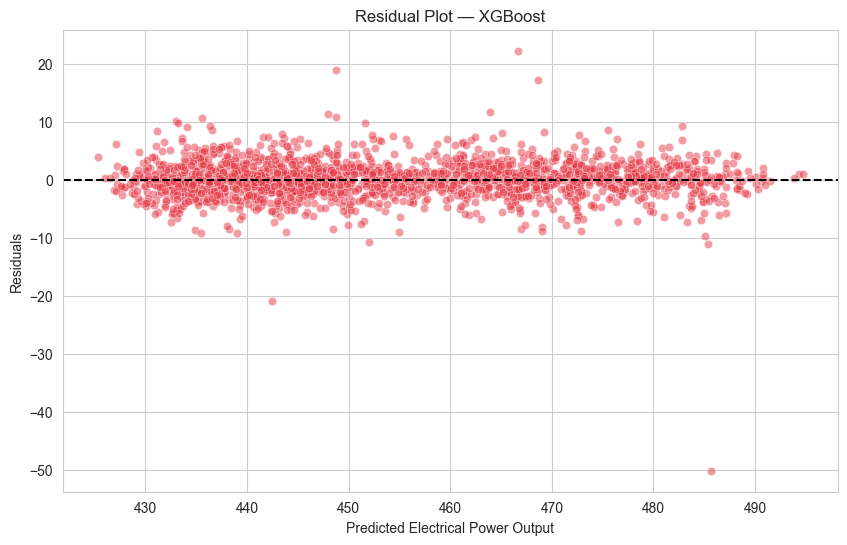

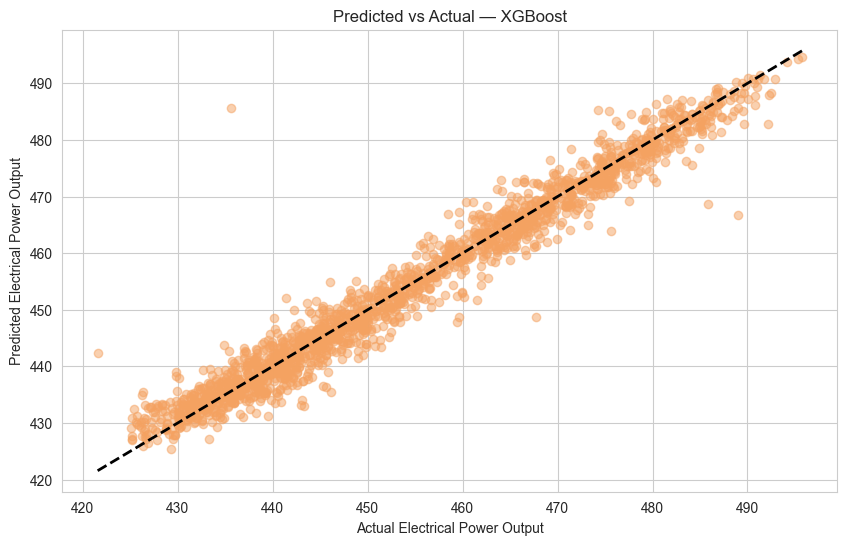


--- VERDICT ---
Good fit: Train R2 (0.9886) and Test R2 (0.9641) are close and reasonably high.


In [16]:
# ============================================================
# CELL 7: Overfitting/Underfitting Evaluation — Best Model
# ============================================================
y_train_pred_best = best_model.predict(X_train_scaled)
y_test_pred_best = best_model.predict(X_test_scaled)

train_r2_best = r2_score(y_train, y_train_pred_best)
test_r2_best = r2_score(y_test, y_test_pred_best)
train_rmse_best = np.sqrt(mean_squared_error(y_train, y_train_pred_best))
test_rmse_best = np.sqrt(mean_squared_error(y_test, y_test_pred_best))

print(f"Best Model: {best_model_name}")
print(f"Train R2: {train_r2_best:.4f} | Test R2: {test_r2_best:.4f}")
print(f"Train RMSE: {train_rmse_best:.4f} | Test RMSE: {test_rmse_best:.4f}")

r2_gap = train_r2_best - test_r2_best

# --- Residual Plot ---
residuals = y_test - y_test_pred_best
plt.figure()
sns.scatterplot(x=y_test_pred_best, y=residuals, color="#e63946", alpha=0.5)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted Electrical Power Output")
plt.ylabel("Residuals")
plt.title(f"Residual Plot — {best_model_name}")
plt.show()

# --- Predicted vs Actual Plot ---
plt.figure()
plt.scatter(y_test, y_test_pred_best, alpha=0.5, color="#f4a261")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
plt.xlabel("Actual Electrical Power Output")
plt.ylabel("Predicted Electrical Power Output")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.show()

# --- Verdict ---
print("\n--- VERDICT ---")
if r2_gap > 0.1:
    print(f"Overfitting detected: Train R2 ({train_r2_best:.4f}) is notably higher than Test R2 ({test_r2_best:.4f}).")
elif train_r2_best < 0.6 and test_r2_best < 0.6:
    print(f"Underfitting detected: Both Train R2 ({train_r2_best:.4f}) and Test R2 ({test_r2_best:.4f}) are low.")
else:
    print(f"Good fit: Train R2 ({train_r2_best:.4f}) and Test R2 ({test_r2_best:.4f}) are close and reasonably high.")

In [17]:
# ============================================================
# CELL 8: Test Best Model on 5 Random Test Rows
# ============================================================
sample_idx = np.random.choice(X_test.index, size=5, replace=False)

sample_X = X_test.loc[sample_idx]
sample_y_actual = y_test.loc[sample_idx]
sample_X_scaled = scaler.transform(sample_X)
sample_y_pred = best_model.predict(sample_X_scaled)

sample_results = pd.DataFrame({
    "Actual": sample_y_actual.values,
    "Predicted": sample_y_pred,
})
sample_results["Error %"] = ((sample_results["Predicted"] - sample_results["Actual"]).abs()
                              / sample_results["Actual"]) * 100

print(f"Sample Predictions using {best_model_name}:")
display(sample_results)

Sample Predictions using XGBoost:


,Actual,Predicted,Error %
0,459.97,460.366821,0.086271
1,426.30,426.021362,0.065362
2,449.87,448.875641,0.221033
3,441.76,438.457336,0.747615
4,465.41,460.939270,0.960600


In [18]:
# ============================================================
# CELL 9: Manual Input Prediction
# ============================================================
print("Enter values for prediction:")
amb_temp = float(input("Ambient Temperature: "))
vacuum = float(input("Vacuum: "))
amb_pressure = float(input("Ambient Pressure: "))
rel_humidity = float(input("Relative Humidity: "))

manual_input = pd.DataFrame([{
    "Ambient Temperature": amb_temp,
    "Vacuum": vacuum,
    "Ambient Pressure": amb_pressure,
    "Relative Humidity": rel_humidity
}])

manual_input_scaled = scaler.transform(manual_input)
manual_pred = best_model.predict(manual_input_scaled)

print(f"\nPredicted Electrical Power Output: {manual_pred[0]:.4f} MW")

Enter values for prediction:


Ambient Temperature:  1010.84
Vacuum:  40.77
Ambient Pressure:  8.34
Relative Humidity:  90.01



Predicted Electrical Power Output: 434.0175 MW


In [19]:
# ============================================================
# CELL 10: Save Trained Model and Scaler
# ============================================================
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print(f"Saved best model ({best_model_name}) as 'best_model.pkl'")
print("Saved scaler as 'scaler.pkl'")

Saved best model (XGBoost) as 'best_model.pkl'
Saved scaler as 'scaler.pkl'
